# Analysis of the Fitness score of from the evolutions

## Setup

In [16]:
# Imports

import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import pandas as pd

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

date = "2026-03-13/"
slurm_job = 16323041

result_dir = result_dir + date+ str(slurm_job) + "/"

runs = [0]
# batches = list(range(0, 100))
# print(batches)
batches = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]

Plotting the evolution of the fitness function of the runs that resulted in interesting behaviour.

batch_1/run_0 finished above 0.99 (final best = 1.0)
batch_2/run_0 finished above 0.99 (final best = 1.0)
batch_3/run_0 finished above 0.99 (final best = 1.0)
batch_5/run_0 finished above 0.99 (final best = 1.0)
batch_7/run_0 finished above 0.99 (final best = 1.0)
batch_8/run_0 finished above 0.99 (final best = 1.0)
batch_22/run_0 finished above 0.99 (final best = 1.0)
batch_24/run_0 finished above 0.99 (final best = 1.0)
batch_27/run_0 finished above 0.99 (final best = 1.0)
batch_29/run_0 finished above 0.99 (final best = 0.999299)
batch_30/run_0 finished above 0.99 (final best = 1.0)
batch_33/run_0 finished above 0.99 (final best = 1.0)
batch_37/run_0 finished above 0.99 (final best = 1.0)
batch_41/run_0 finished above 0.99 (final best = 1.0)
batch_45/run_0 finished above 0.99 (final best = 1.0)
batch_52/run_0 finished above 0.99 (final best = 0.998891)
batch_54/run_0 finished above 0.99 (final best = 0.991053)
batch_57/run_0 finished above 0.99 (final best = 1.0)
batch_61/run_0 fini

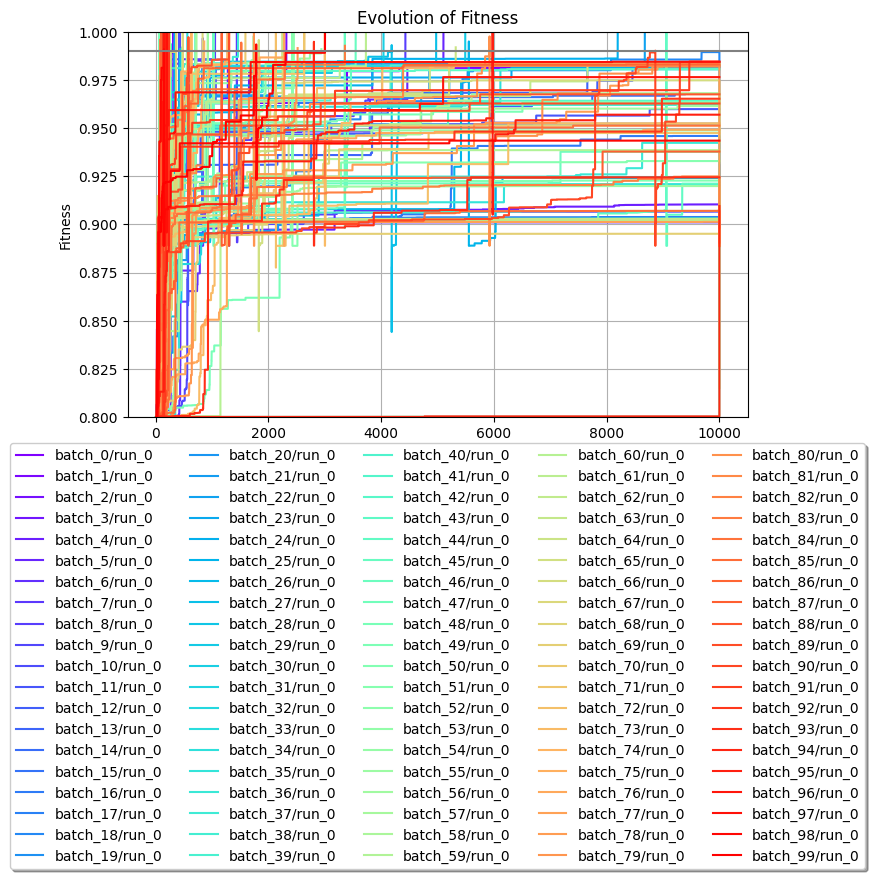

[1, 2, 3, 5, 7, 8, 22, 24, 27, 29, 30, 33, 37, 41, 45, 52, 54, 57, 61, 64, 67, 70, 74, 75, 79, 83, 99]


In [17]:


plt.figure(figsize=(8,5))

colors = plt.cm.rainbow(np.linspace(0, 1, len(runs)*len(batches)))
counter = 0

good_plots = []

for batch in batches:
    for run in runs:
        overall_evolution_dir = result_dir + "batch_"+str(batch)+"/run_"+str(run)+"/evol_" + str(run) + ".dat"
        # pass the input
        df = pd.read_csv(
            overall_evolution_dir,
            sep=r"\s+",
            header=None,
            names=["generation", "best_fitness", "avg_fitness"]
        )

        generation = df["generation"].to_numpy()
        best = df["best_fitness"].to_numpy()
        average = df["avg_fitness"].to_numpy()

        label_name = "batch_" + str(batch)+"/run_"+str(run)

        plt.plot(generation, best, 
                linestyle="-", 
                label=label_name,
                color=colors[counter],
            )
    
        # ---- CHECK FINAL FITNESS ----
        final_best = best[-1]
        if final_best > 0.99:
            print(f"{label_name} finished above 0.99 (final best = {final_best})")
            good_plots.append(batch)


        counter += 1

plt.axhline(0.99, color ='grey')

plt.ylim(top = 1, bottom=0.8)
# plt.xlim(right = 4000)

plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Evolution of Fitness")

# Put a legend below current axis
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)
plt.grid(True)

plt.show()

print(good_plots)
    

same plot of evolution, but they are now split into groups (the same as chunk size)

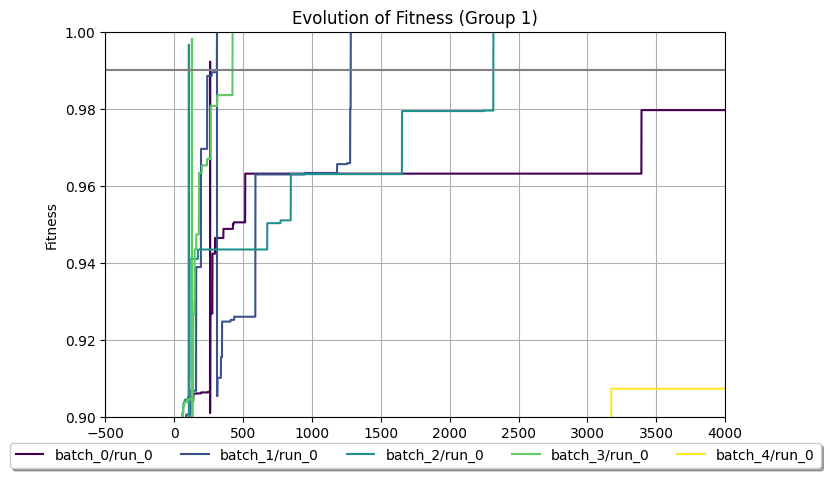

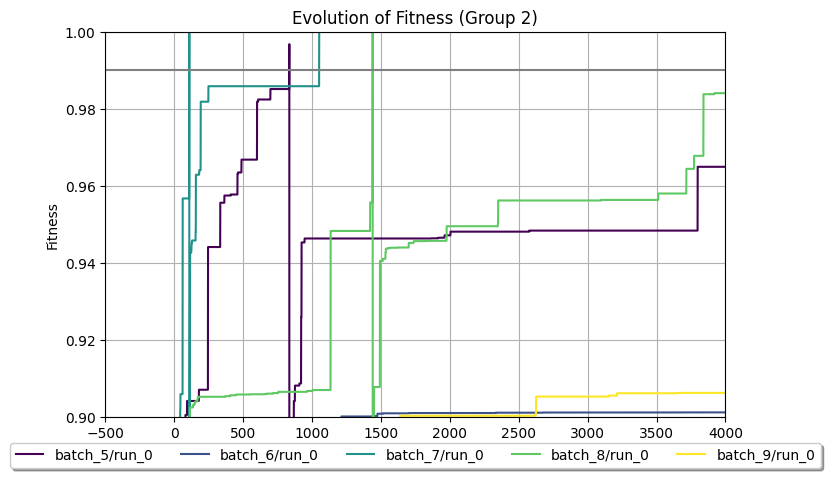

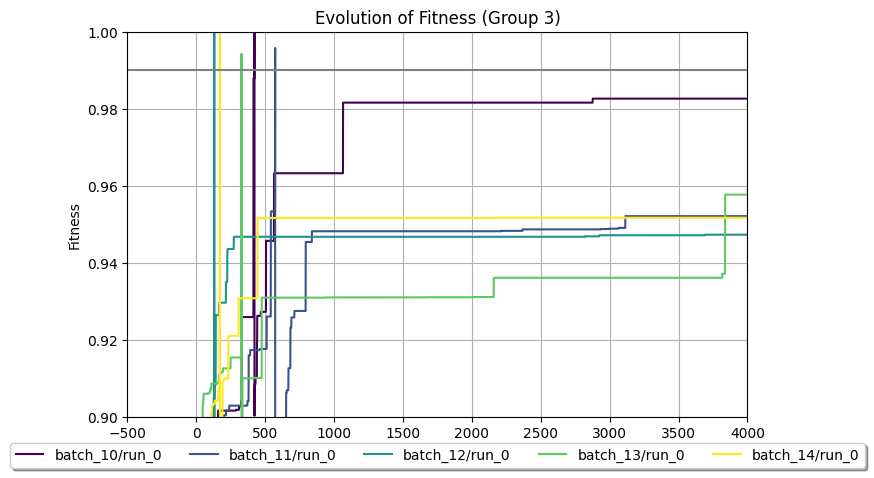

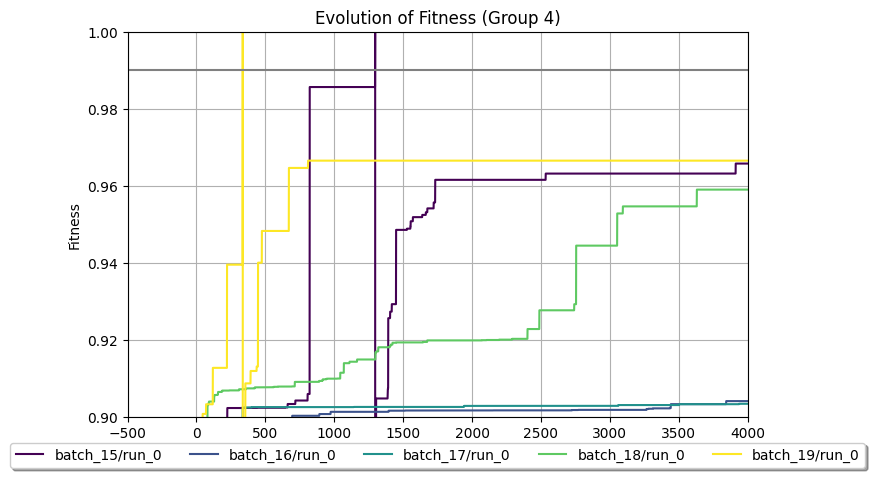

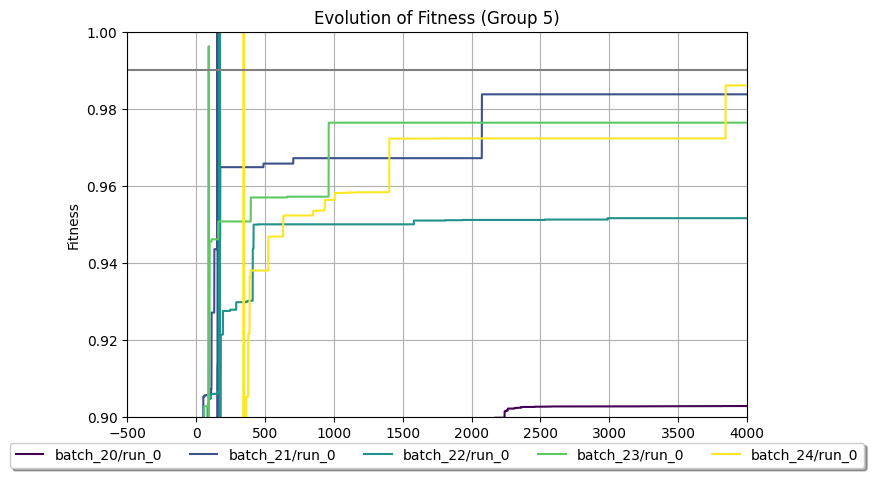

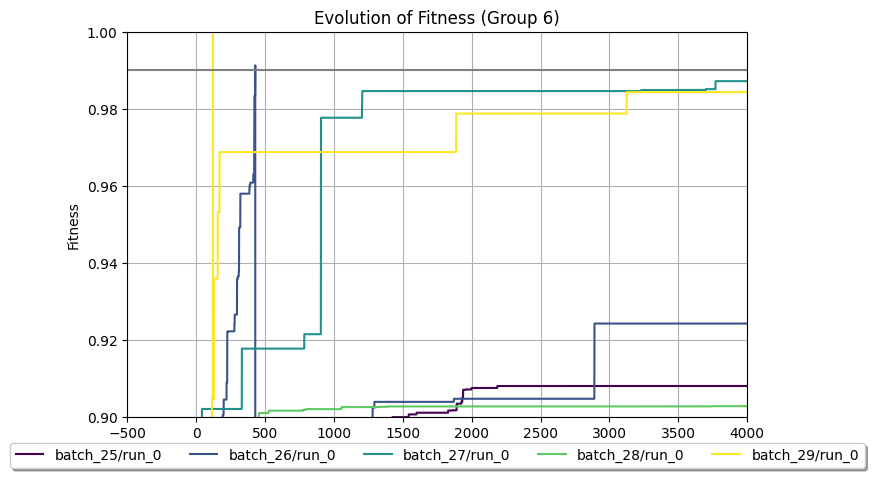

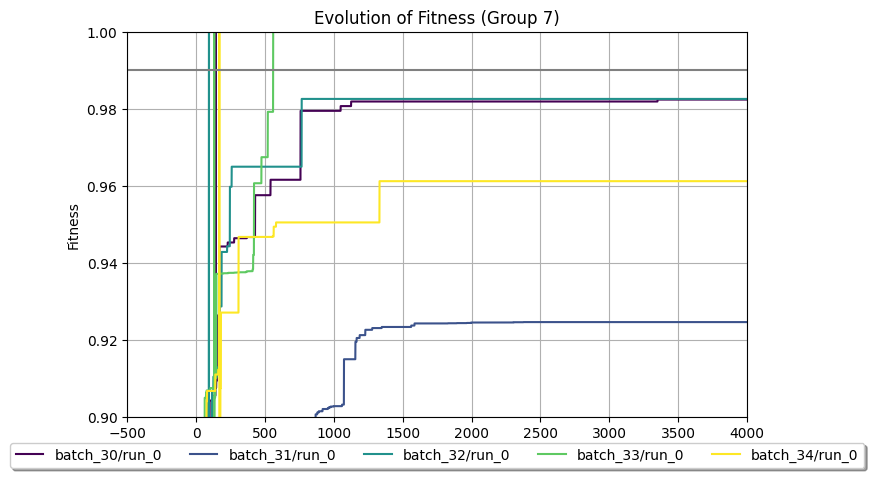

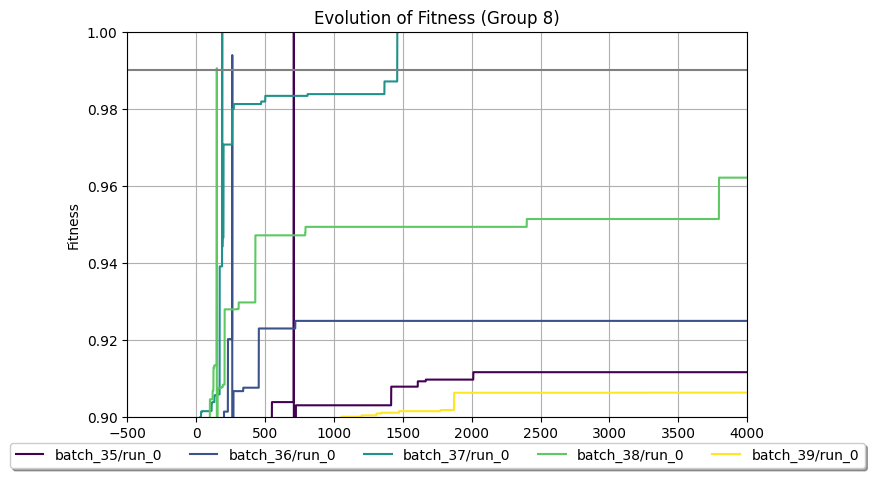

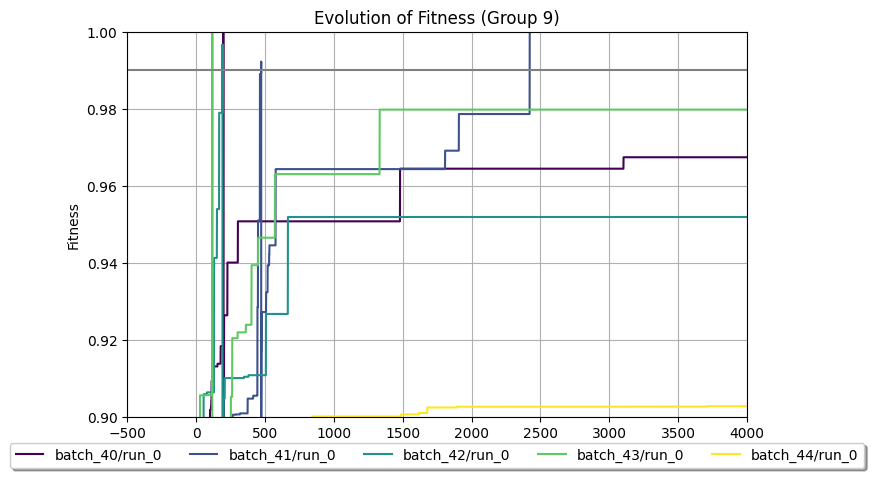

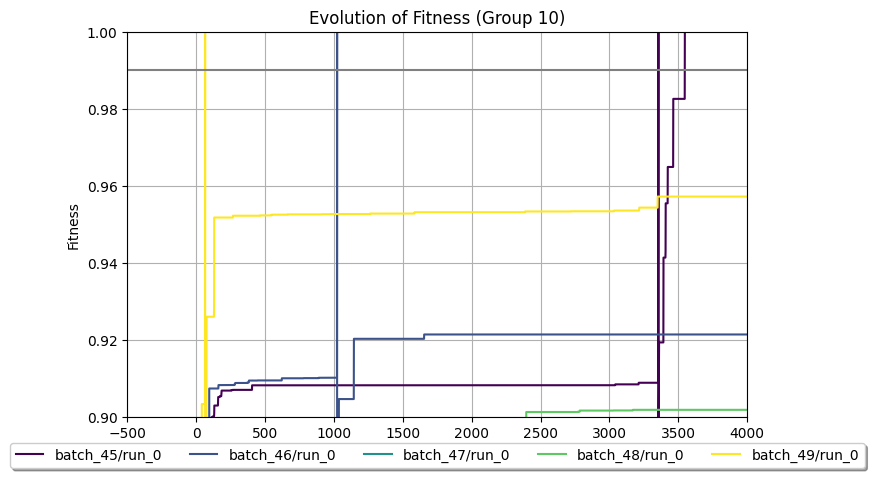

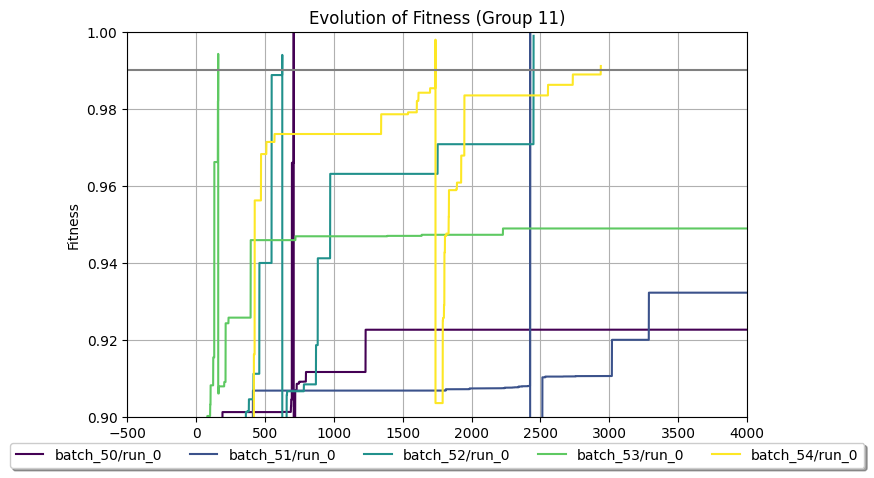

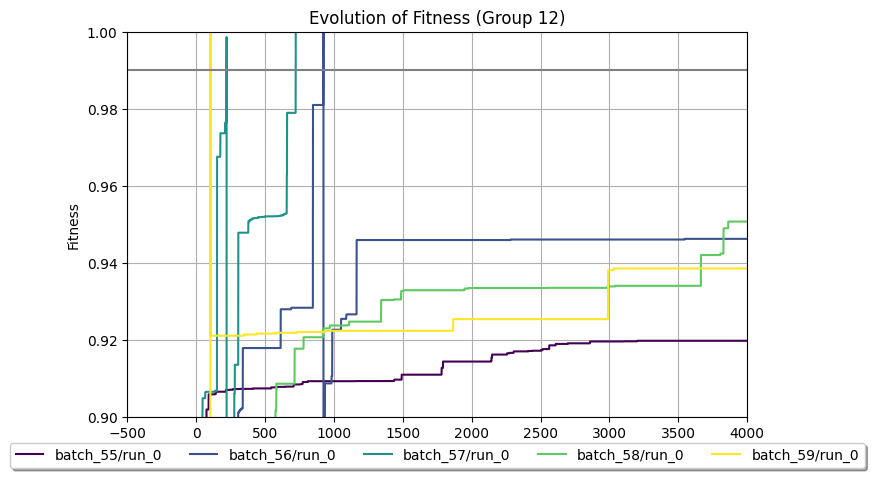

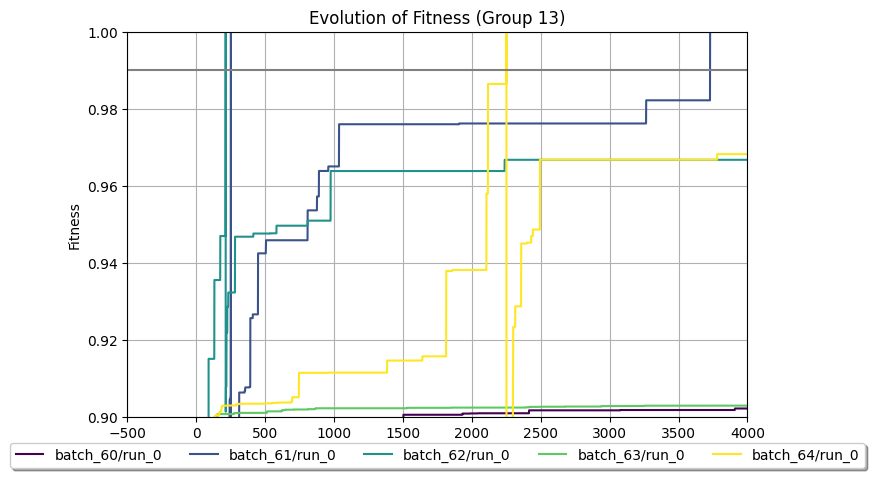

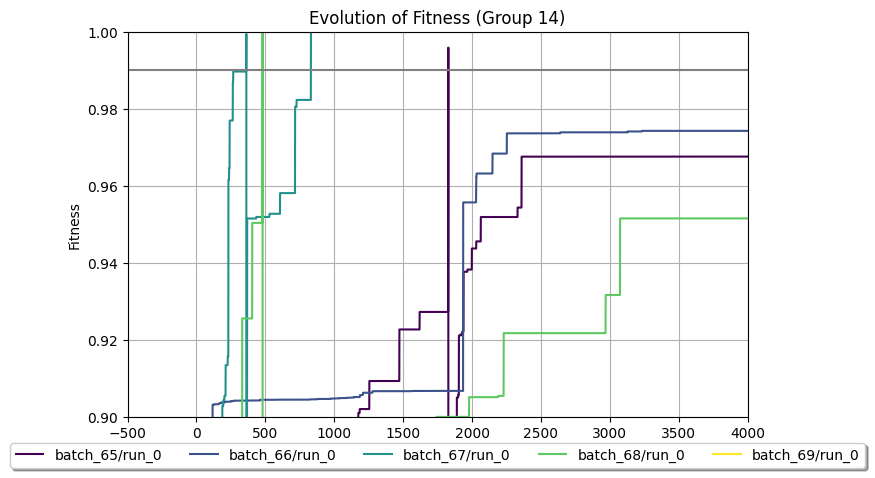

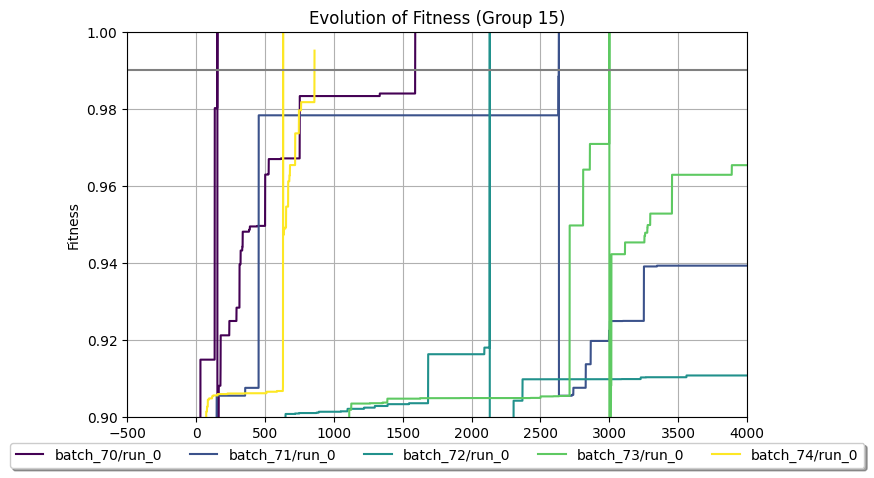

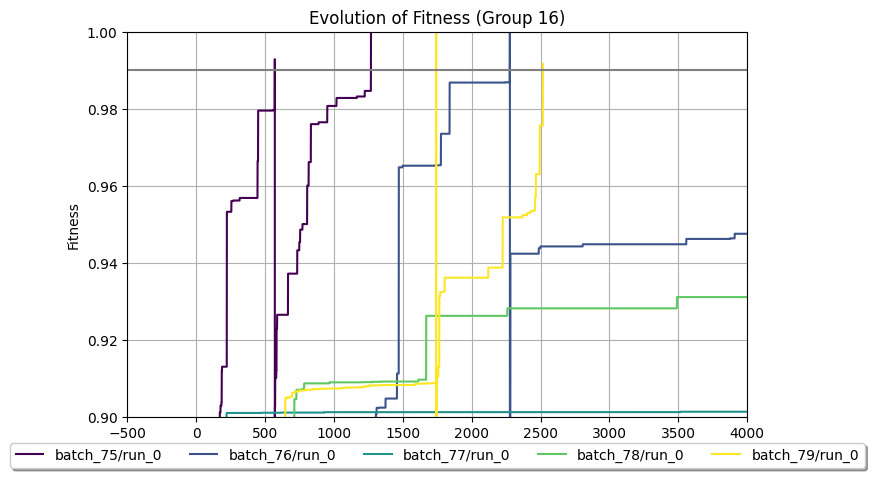

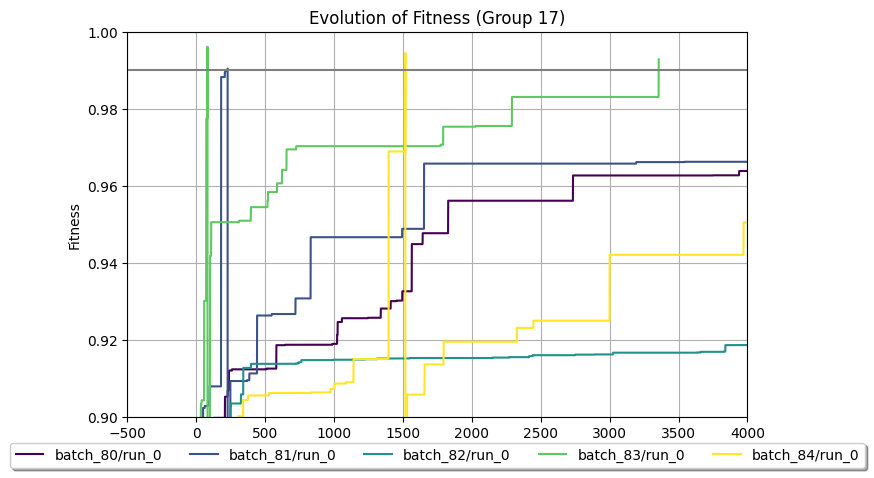

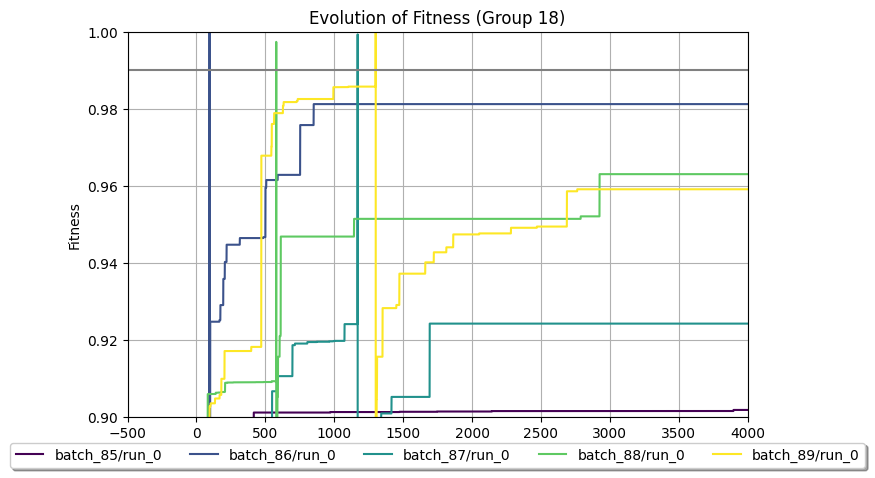

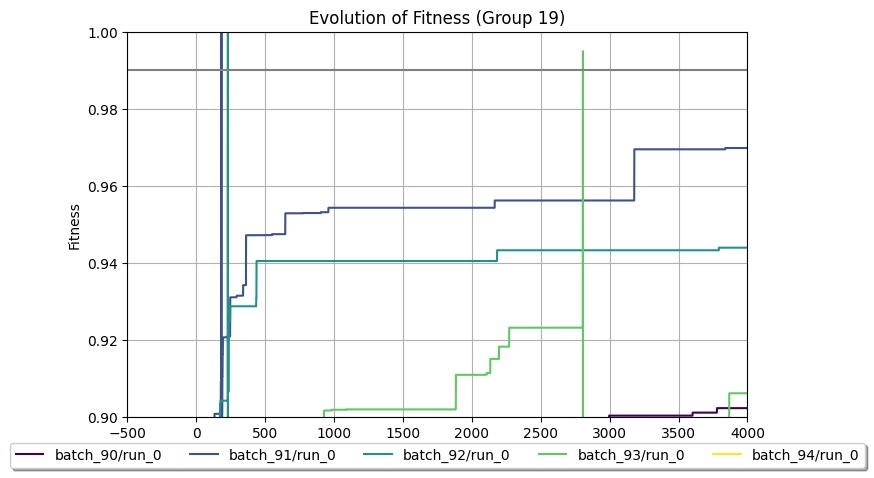

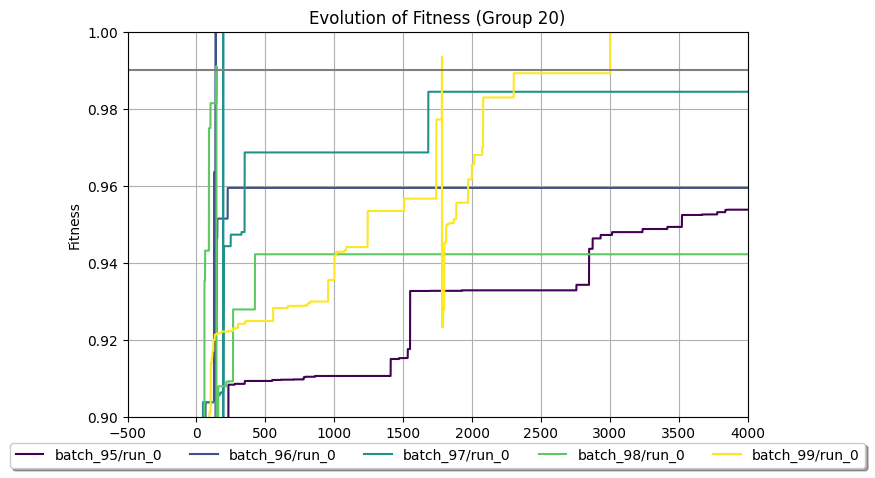

In [18]:

chunk_size = 5

# Split batches into chunks of 5
batch_groups = [batches[i:i+chunk_size] for i in range(0, len(batches), chunk_size)]
for group_idx, batch_group in enumerate(batch_groups):
    plt.figure(figsize=(8,5))
    colors = plt.cm.viridis(np.linspace(0, 1, len(batch_group)*len(runs)))
    counter = 0

    for batch in batch_group:
        for run in runs:
            overall_evolution_dir = result_dir + "batch_"+str(batch)+"/run_"+str(run)+"/evol_" + str(run) + ".dat"
            # pass the input
            df = pd.read_csv(
                overall_evolution_dir,
                sep=r"\s+",
                header=None,
                names=["generation", "best_fitness", "avg_fitness"]
            )

            generation = df["generation"].to_numpy()
            best = df["best_fitness"].to_numpy()
            average = df["avg_fitness"].to_numpy()

            label_name = "batch_" + str(batch)+"/run_"+str(run)

            plt.plot(generation, best, 
                    linestyle="-", 
                    label=label_name,
                    color=colors[counter],
                )

            plt.plot(generation, average, 
                    linestyle=":", 
                    color=colors[counter],
                )
            counter += 1

    plt.axhline(0.99, color ='grey')

    plt.ylim(top = 1, bottom=0.9)
    plt.xlim(right = 4000)

    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.title(f"Evolution of Fitness (Group {group_idx+1})")
    # Put a legend below current axis
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
            fancybox=True, shadow=True, ncol=5)
    plt.grid(True)

    plt.show()
    